In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2
import math
import os
from DINOv2 import DINOv2
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [32]:
img_path = 'imgs/nut_2.jpg'
X = cv2.imread(img_path, cv2.IMREAD_COLOR)
assert X is not None, f"Image not found: {img_path}"
X = cv2.cvtColor(X, cv2.COLOR_BGR2RGB)

h, w = X.shape[:2]
long_side_target = 1440
scale = long_side_target / max(h, w)
new_w = int(round(w * scale))
new_h = int(round(h * scale))

# 调整到14的倍数（patch size），用四舍五入减少形变
patch = 14
new_w = max(patch, int(round(new_w / patch)) * patch)
new_h = max(patch, int(round(new_h / patch)) * patch)

X = cv2.resize(X, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

X = X.astype(np.float32)
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
X = (X / 255.0 - mean) / std
X = X.transpose(2, 0, 1)  # (C,H,W)
X = torch.from_numpy(X).unsqueeze(0).to("cuda")  # (1,C,H,W)

In [33]:
model = DINOv2(model_name='dinov2_vitb14', return_attn_maps=True).to("cuda")

In [34]:
model.eval()
with torch.no_grad():
    f, attn = model(X)
    # f = f.detach().cpu().numpy()


q, k, v shapes: torch.Size([1, 7932, 12, 64]) torch.Size([1, 7932, 12, 64]) torch.Size([1, 7932, 12, 64])
torch.Size([1, 12, 7932, 7932])


In [35]:
B, H, Hh, Ww = attn.shape
N = Hh * Ww
a = attn.view(B, H, N)
mu = a.mean(-1, keepdim=True)
sd = a.std(-1, keepdim=True).clamp_min(1e-6)
z = (a - mu) / sd
w_hn = torch.sigmoid(z)  # (B,H,N)
w_hn = w_hn.pow(2)
attn = w_hn.view(B,H,Hh,Ww)

In [36]:
a_abs = torch.abs(a)
a_sum = a.sum(-1, keepdim=True) + 1e-6
a_norm = a_abs / a_sum
entropy = -(a_norm * torch.log(a_norm.clamp_min(1e-8))).sum(-1) / math.log(N)   # (B,H) ∈ [0,1]
s_h = (w_hn.mean(-1) * (1.0 - entropy)).clamp_min(1e-6)           

In [37]:
s_h

tensor([[0.0268, 0.0041, 0.0035, 0.0168, 0.0063, 0.0075, 0.0105, 0.0291, 0.0118,
         0.0026, 0.0013, 0.0136]], device='cuda:0')

In [38]:
G_raw = nn.Parameter(torch.ones(32, 12)).to("cuda")
G_pos = F.softplus(G_raw)                                   # (K,H) ≥ 0
prod = G_pos.unsqueeze(0) * s_h.unsqueeze(1)                     # (B,K,H)
g_bkh = torch.softmax((prod + 1e-6).log(), dim=-1)           # (B,K,H)


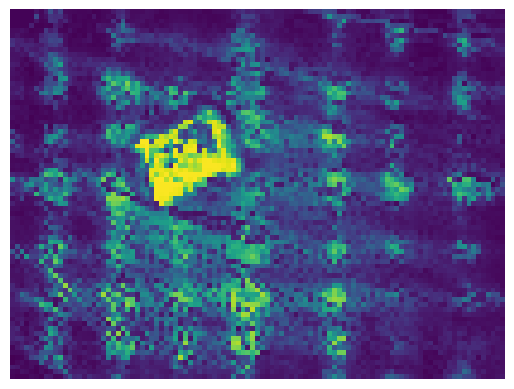

In [39]:
cls_attn = attn[0]# [num_heads, N, N]
attn_head = cls_attn[4].detach().cpu().numpy()
# f_pca = f[6]  # 选择第一个注意力头

attn_img = attn_head.reshape(attn_head.shape[0], attn_head.shape[1], 1)

# 归一化到0-255
attn_img -= attn_img.min()
attn_img /= attn_img.max()
attn_img = (attn_img * 255).astype(np.uint8)

plt.imshow(attn_img)
plt.axis('off')
plt.show()

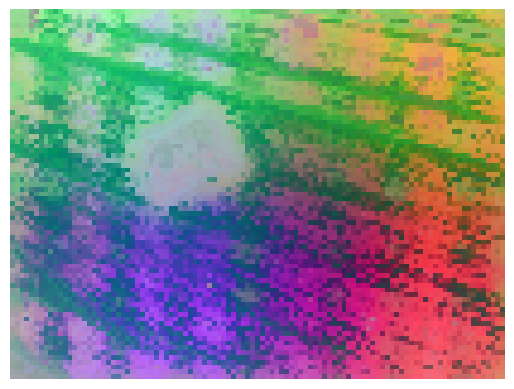

In [40]:
from sklearn.decomposition import PCA

# f shape: (C, H, W)
f = f[0]  # 去掉batch维度
f = f.detach().cpu().numpy()
# f_pca = f[6]  # 选择第一个注意力头
C, H, W = f.shape
f_flat = f.reshape(C, -1).T  # shape: (H*W, C)

pca = PCA(n_components=3)
f_pca = pca.fit_transform(f_flat)  # shape: (H*W, 3)
f_pca_img = f_pca.reshape(H, W, 3)

# 归一化到0-255
f_pca_img -= f_pca_img.min()
f_pca_img /= f_pca_img.max()
f_pca_img = (f_pca_img * 255).astype(np.uint8)

plt.imshow(f_pca_img)
plt.axis('off')
plt.show()